# **Penyeimbangan dataset (SMOTE, ADASYN)**

# **Download data, simpan di MYSQL**

Gambar di bawah ini merupakan Repository yang menyimpan informasi mengenai lokasi protein. Di laman ini, terdapat ringkasan mengenai **karakteristik dataset (multivariat), bidang penelitian (biologi), jenis tugas (klasifikasi), jumlah instance (336 data), jumlah fitur (7 atribut), serta penjelasan bahwa dataset ini tidak memiliki nilai yang hilang. Untuk mengunduh dataset ini, pengguna dapat mengeklik tombol DOWNLOAD (5. 5 KB)** yang terletak di sisi kanan halaman, sehingga file dataset akan terunduh dalam format teks atau CSV yang siap digunakan untuk analisis atau pemodelan machine learning.

---

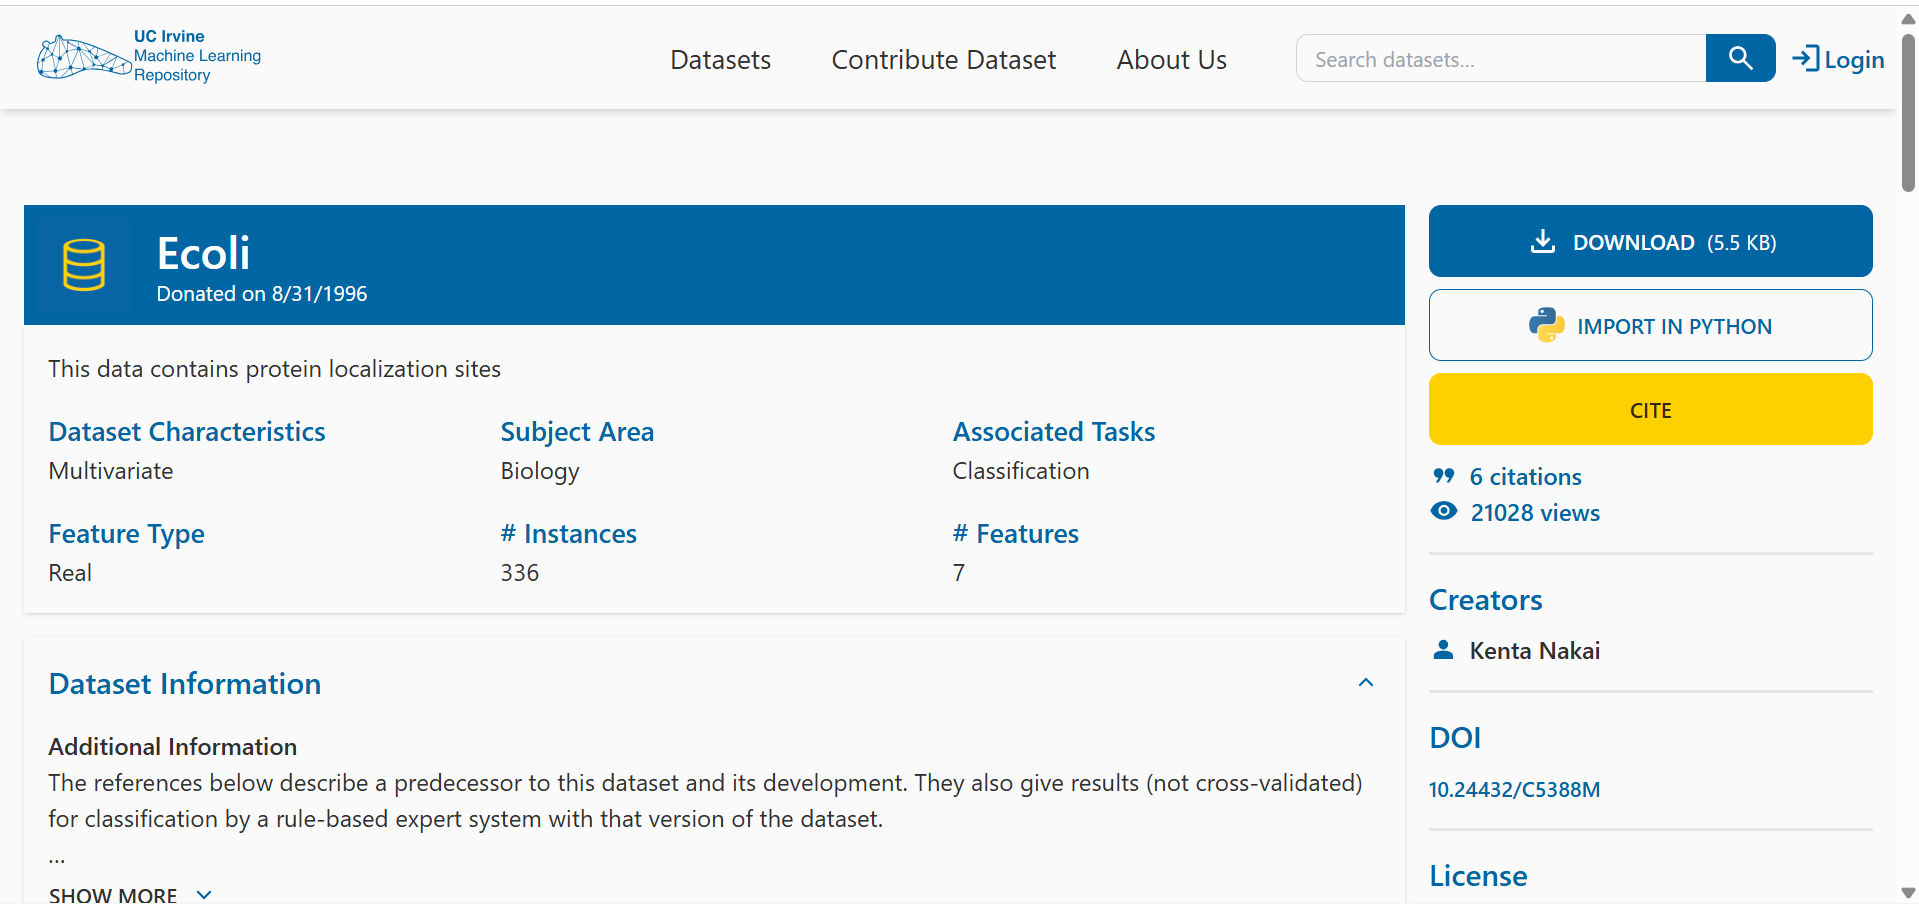


Gambar di bawah menunjukkan antarmuka phpMyAdmin saat mengimpor dataset Ecoli (dalam format. csv) ke dalam MySQL. Setelah mengunduh dataset dari UCI Repository, langkah selanjutnya adalah melakukan impor file agar dapat disimpan dan dikelola di database MySQL. Prosesnya adalah sebagai berikut:

- Masuk ke phpMyAdmin → pilih database yang ingin digunakan (misalnya ecoli_dataset).

- Klik menu Impor.

- Di bagian Berkas untuk impor, tekan Choose File dan pilih file ecoli_dataset. csv yang telah diunduh.

- Pastikan Set karakter berkas disetel ke utf-8 agar data dapat terbaca dengan baik.

- Pada bagian Format, pilih CSV.

- Gulir ke bawah dan tekan tombol Go untuk memulai proses impor.

Setelah itu, MySQL akan membuat tabel yang berisi data dari file CSV tersebut. Jika file CSV tidak memiliki struktur tabel (nama kolom), biasanya Anda perlu menyesuaikan pengaturan seperti Fields terminated by (misalnya , untuk koma) dan menetapkan nama tabel atau kolom secara manual. Dengan cara ini, dataset dari UCI bisa digunakan untuk query SQL, analisis, dan integrasi dengan aplikasi Anda.

---

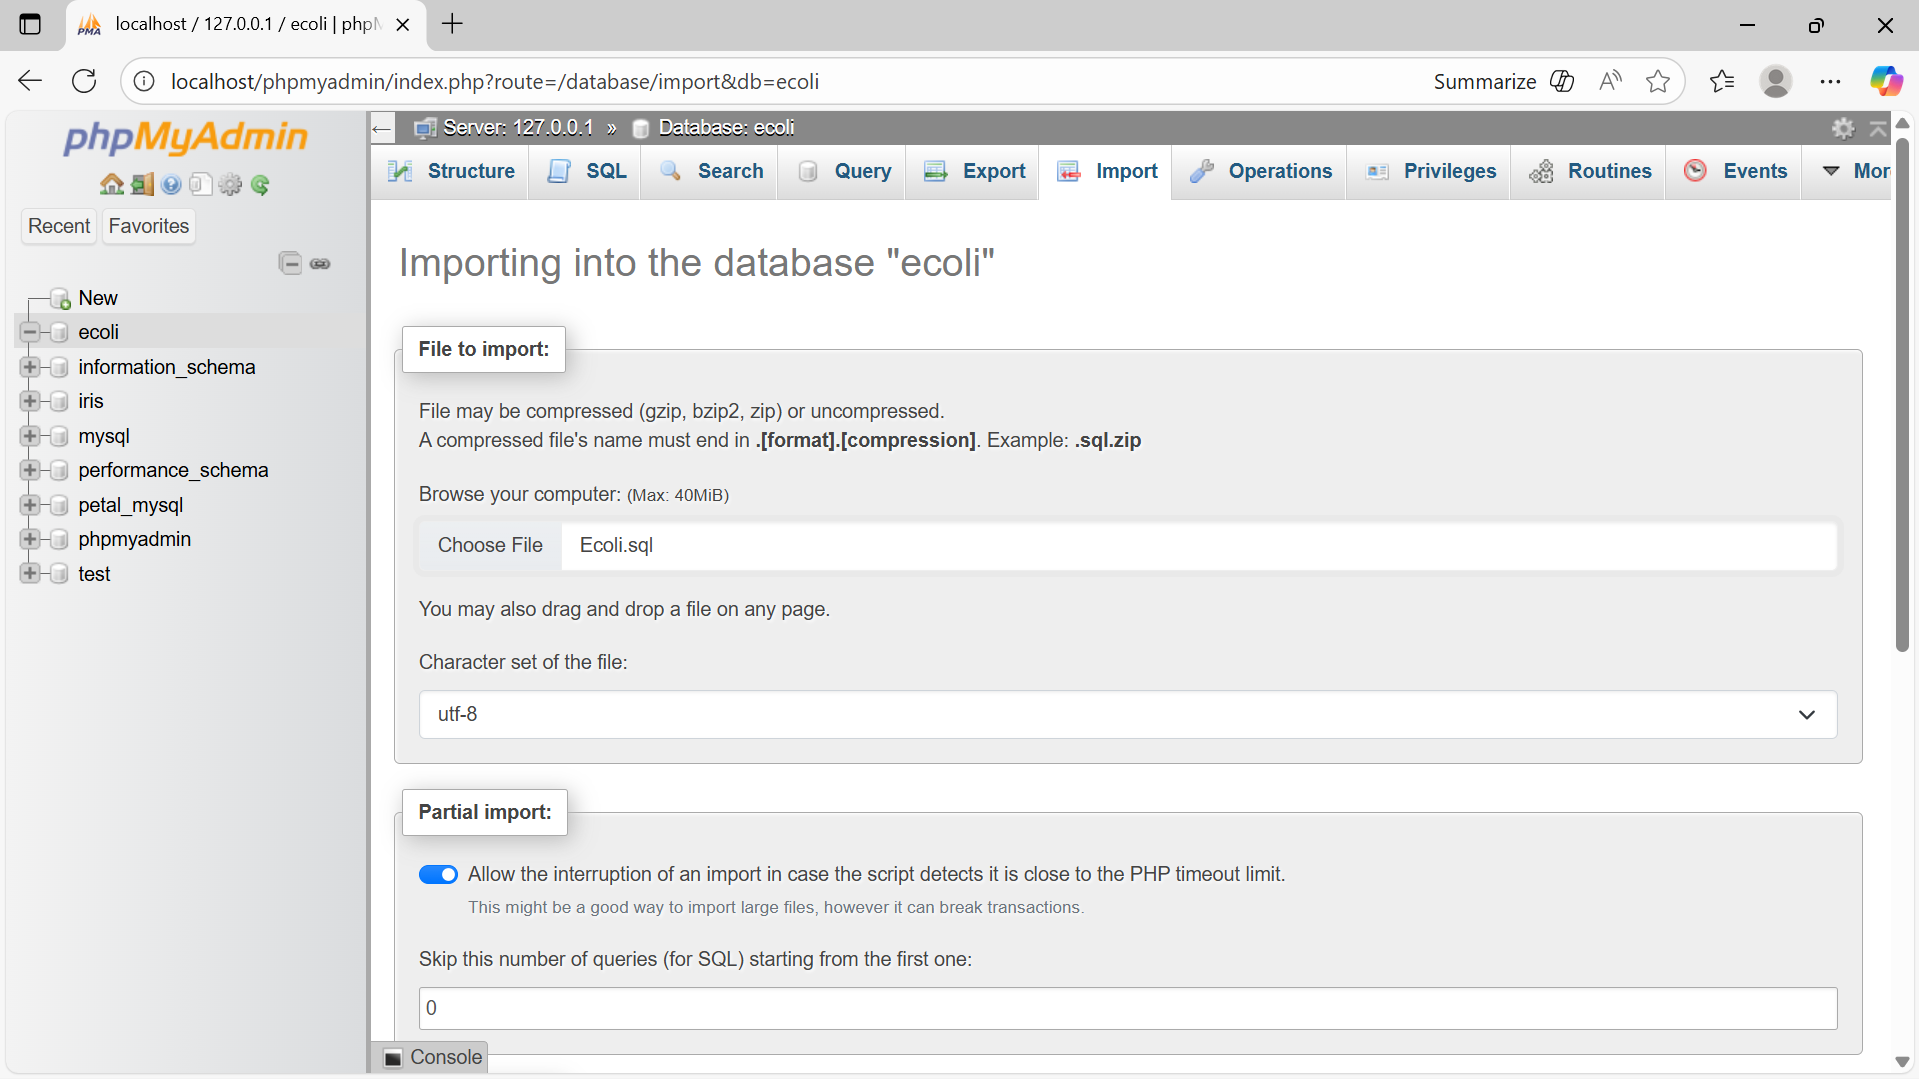

# **Installing library**

In [1]:
pip install mysql-connector-python imbalanced-learn scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.9/33.9 MB 40.0 MB/s eta 0:00:00


# **Menghubungkan dan menginisialisasi dataset awal**

---

Kode Python berikut bertujuan untuk mengunduh dataset Ecoli dari UCI Machine Learning Repository dan menyimpannya dalam format DataFrame dengan memanfaatkan pustaka pandas. Pada bagian awal, semua pustaka yang diperlukan dimuat, termasuk pandas, numpy, matplotlib, seaborn, serta modul dari scikit-learn (StandardScaler, PCA), dan ADASYN dari imbalanced-learn untuk menyeimbangkan data. Selain itu, terdapat sqlalchemy yang nantinya akan digunakan untuk menghubungkan ke database MySQL. Variabel konfigurasi untuk database seperti MYSQL_USER, MYSQL_PASS, MYSQL_HOST, MYSQL_PORT, dan MYSQL_DB telah ditetapkan sebelumnya agar mempermudah proses penyimpanan data ke dalam MySQL.

Selanjutnya, ditentukan URL dataset (ecoli. data) serta daftar nama kolom sesuai yang tercantum dalam dokumentasi UCI, termasuk atribut-atribut seperti mcg, gvh, lip, chg, aac, alm1, alm2, dan class sebagai label bagi kelas. Dataset ini kemudian dibaca menggunakan pd. read_csv() dengan parameter sep=r"\s+" karena data dipisahkan oleh spasi atau tab. Hasil pembacaan disimpan di dalam DataFrame dengan nama df, kemudian ukuran datanya ditampilkan menggunakan df. shape dan lima baris awal menggunakan df. head(). Proses ini merupakan langkah awal untuk memastikan bahwa data telah berhasil diunduh dan terbaca dengan baik sebelum melanjutkan pada analisis lebih lanjut seperti PCA, visualisasi, atau penyeimbangan data dengan ADASYN.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import ADASYN
from sqlalchemy import create_engine


MYSQL_USER = "root"
MYSQL_PASS = ""
MYSQL_HOST = "127.0.0.1"
MYSQL_PORT = 3306
MYSQL_DB   = "ecoli"
TABLE_NAME = "ecoli_dataset"

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data"

col_names = ["seq_name", "mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2", "class"]

df = pd.read_csv(url, header=None, sep=r"\s+", names=col_names)
print("Shape:", df.shape)
print(df.head())


Shape: (336, 9)
     seq_name   mcg   gvh   lip  chg   aac  alm1  alm2 class
0   AAT_ECOLI  0.49  0.29  0.48  0.5  0.56  0.24  0.35    cp
1  ACEA_ECOLI  0.07  0.40  0.48  0.5  0.54  0.35  0.44    cp
2  ACEK_ECOLI  0.56  0.40  0.48  0.5  0.49  0.37  0.46    cp
3  ACKA_ECOLI  0.59  0.49  0.48  0.5  0.52  0.45  0.36    cp
4   ADI_ECOLI  0.23  0.32  0.48  0.5  0.55  0.25  0.35    cp


# **Visualisasi Data dengan PCA**

---

Kode di atas ditujukan untuk menganalisis dan mempresentasikan dataset Ecoli dengan dua metode berbeda. Pertama, dibuatlah pairplot menggunakan seaborn untuk beberapa fitur numerik penting (mcg, gvh, lip, chg, aac, alm1, alm2) dengan mengatur label kelas sebagai hue. Pairplot ini menunjukkan distribusi marginal setiap fitur di garis diagonal, serta menampilkan sebaran dan hubungan antar fitur pada plot scatter di luar garis diagonal. Visualisasi ini berguna untuk memahami pola dasar, interaksi antar fitur, dan bagaimana distribusi kelas-kelas Ecoli berada dalam ruang fitur asli sebelum dilakukan pengurangan dimensi.

Kemudian, data dinormalisasi menggunakan StandardScaler agar seluruh fitur memiliki skala yang seragam, dan dilanjutkan dengan Principal Component Analysis (PCA) untuk mereduksi data menjadi dua dimensi (PC1 dan PC2). Hasil dari transformasi PCA tersebut disimpan dalam DataFrame baru yang dinamai df_plot, kemudian divisualisasikan dalam bentuk scatter plot. Setiap titik dalam plot itu mewakili satu sampel, dengan warna yang mencerminkan kelasnya. Plot PCA ini memudahkan dalam mengidentifikasi pola dan perbedaan antara kelas dalam ruang dua dimensi, sehingga dapat dibandingkan dengan sebaran asli dari pairplot, terutama untuk mengamati tumpang tindih atau pengelompokan dari tiap kelas.

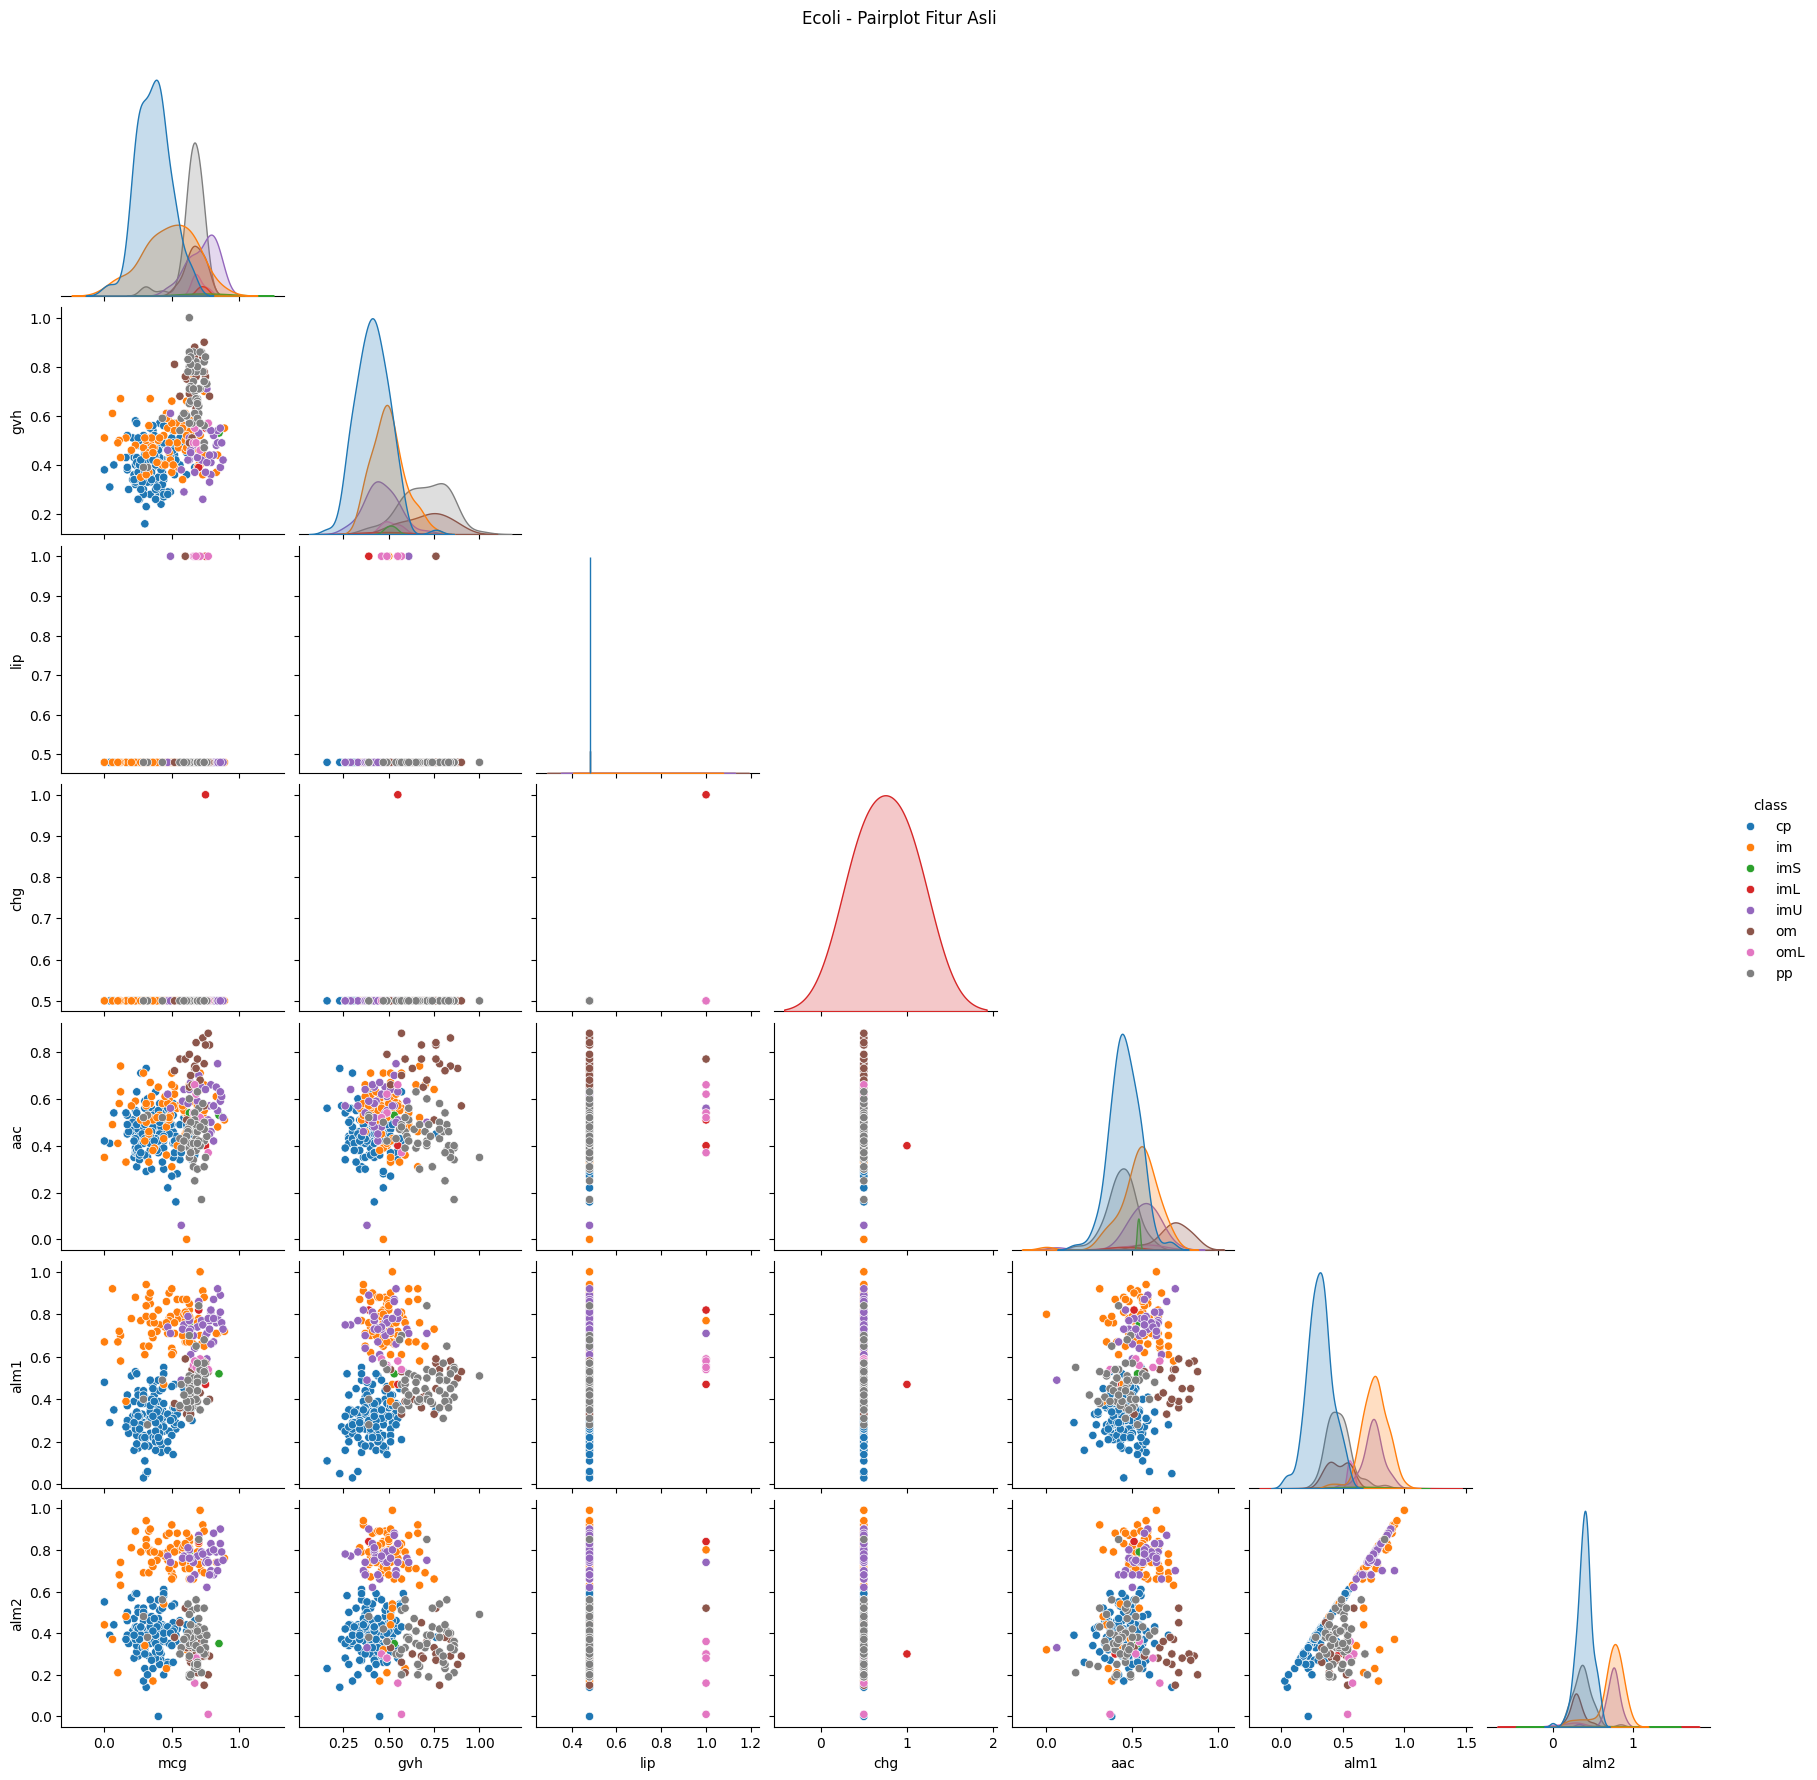

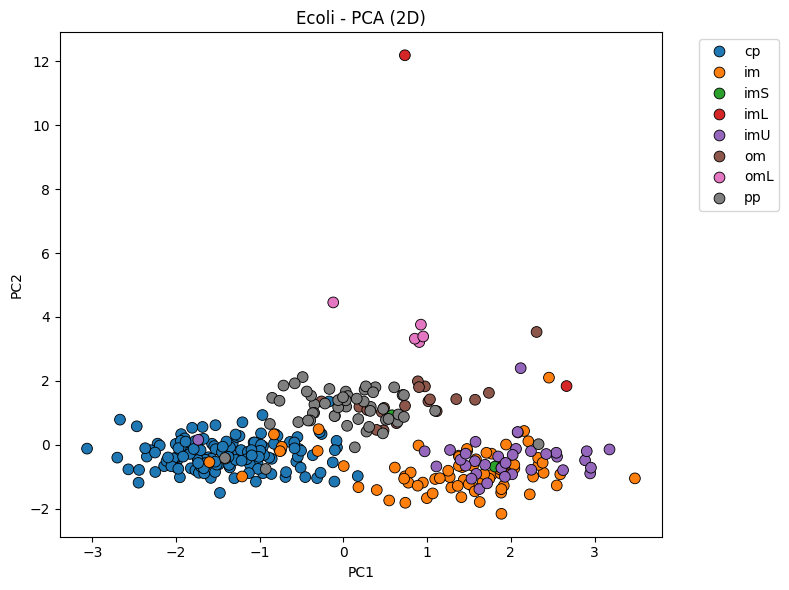

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ["mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2"]
X = df[features]
y = df["class"]

df_pair = X.copy()
df_pair["class"] = y
sns.pairplot(df_pair, hue="class", corner=True, diag_kind="kde", palette="tab10")
plt.suptitle("Ecoli - Pairplot Fitur Asli", y=1.02)
plt.show()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_plot = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "class": y
})

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="class", palette="tab10", s=60, edgecolor="k")
plt.title("Ecoli - PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()


# **Penyeimbangan Data**

## **SMOTE**

---

Potongan kode berikut digunakan untuk menyeimbangkan kelas dalam dataset Ecoli dengan menggunakan metode SMOTE (Synthetic Minority Oversampling Technique). Dalam tahap awal, fitur numerik utama ditetapkan sebagai X dan label kelas ditetapkan sebagai y. Kemudian, SMOTE diterapkan dengan menetapkan parameter k_neighbors=1 untuk mencegah kesalahan pada kelas minoritas yang memiliki jumlah sampel yang sangat terbatas. Fungsi fit_resample dari SMOTE menghasilkan X_res dan y_res, yaitu dataset baru yang telah disesuaikan sehingga setiap kelas memiliki jumlah sampel yang hampir serupa. Kode juga menunjukkan jumlah sampel per kelas sebelum dan sesudah proses penyeimbangan dengan menggunakan pd. Series. value_counts() untuk mempermudah pengujian efek dari oversampling.

Selanjutnya, kode ini menandai sampel sintetis yang dihasilkan oleh SMOTE dengan membandingkan setiap baris dari hasil resampling X_res dengan data asli X. Fungsi rows_to_keys berfungsi untuk mengubah setiap baris menjadi string unik berdasarkan nilai-nilai fitur yang dibulatkan, sehingga dapat dilakukan perbandingan yang akurat. Variabel is_synthetic mendalami boolean yang menunjukkan apakah baris tersebut adalah sampel yang dihasilkan oleh SMOTE (True) atau berasal dari data asli (False). Dengan cara ini, kita dapat mengetahui jumlah sampel baru yang ditambahkan, yang sangat berguna untuk visualisasi dan analisis lebih lanjut, contohnya saat ingin menampilkan scatter plot PCA dengan menandai data sintetis.

In [5]:

from imblearn.over_sampling import SMOTE

features = ["mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2"]
X = df[features].values
y = df["class"].values

smote = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = smote.fit_resample(X, y)

print("Before balancing:", pd.Series(y).value_counts().to_dict())
print("After  balancing:", pd.Series(y_res).value_counts().to_dict())

# tandai synthetic samples
def rows_to_keys(arr):
    arr_rounded = np.round(arr.astype(float), 8)
    keys = ["|".join(map(str, row)) for row in arr_rounded]
    return np.array(keys)

orig_keys = rows_to_keys(X)
res_keys  = rows_to_keys(X_res)
orig_key_set = set(orig_keys.tolist())
is_synthetic = np.array([k not in orig_key_set for k in res_keys])

print("Jumlah sampel resampled:", len(X_res))
print("Jumlah synthetic terdeteksi:", is_synthetic.sum())


Before balancing: {'cp': 143, 'im': 77, 'pp': 52, 'imU': 35, 'om': 20, 'omL': 5, 'imL': 2, 'imS': 2}
After  balancing: {'cp': 143, 'im': 143, 'imS': 143, 'imL': 143, 'imU': 143, 'om': 143, 'omL': 143, 'pp': 143}
Jumlah sampel resampled: 1144
Jumlah synthetic terdeteksi: 808


## **ADASYN**

---

Potongan kode ini memperlihatkan metode campuran untuk menyeimbangkan dataset Ecoli yang memiliki kelas yang sangat sedikit. Pertama, digunakan SMOTE dengan `k_neighbors=1` untuk meningkatkan jumlah sampel di kelas-kelas yang sangat minim, sehingga setiap kelas memiliki jumlah sampel yang memadai. Hasil dari resampling disimpan dalam `X_sm` dan `y_sm`, serta jumlah sampel untuk setiap kelas ditampilkan menggunakan `pd. Series. value_counts()`, memungkinkan kita melihat dampak dari penambahan sampel sintetis oleh SMOTE.

Setelah kelas ultra-minoritas cukup terwakili, diterapkan ADASYN pada dataset yang telah dihasilkan oleh SMOTE. ADASYN juga menggunakan `n_neighbors=1` untuk memastikan proses dapat berjalan tanpa masalah pada kelas minoritas yang sangat kecil. Metode ini menciptakan sampel sintetis yang lebih cocok berdasarkan distribusi kelas mayoritas di sekitar sampel minoritas. Hasil akhirnya disimpan pada `X_ada` dan `y_ada`, dan jumlah sampel per kelas diperlihatkan kembali. Dengan penerapan metode gabungan ini, dataset menjadi lebih seimbang dan siap untuk dianalisis atau divisualisasikan lebih lanjut, contohnya menggunakan PCA untuk mengamati distribusi sampel asli dan sintetis.

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN

# 1. SMOTE dulu untuk mengatasi kelas ultra-minoritas
smote = SMOTE(random_state=42, k_neighbors=1)
X_sm, y_sm = smote.fit_resample(X_scaled, y)

print("Setelah SMOTE:", pd.Series(y_sm).value_counts().to_dict())

# 2. Baru jalankan ADASYN di hasil SMOTE
adasyn = ADASYN(random_state=42, n_neighbors=1)
X_ada, y_ada = adasyn.fit_resample(X_sm, y_sm)

print("Setelah SMOTE+ADASYN:", pd.Series(y_ada).value_counts().to_dict())


Setelah SMOTE: {'cp': 143, 'im': 143, 'imS': 143, 'imL': 143, 'imU': 143, 'om': 143, 'omL': 143, 'pp': 143}
Setelah SMOTE+ADASYN: {'cp': 143, 'im': 143, 'imS': 143, 'imL': 143, 'imU': 143, 'om': 143, 'omL': 143, 'pp': 143}


# **Visualisasi data akhir**

---

Kode ini berfungsi untuk menggambarkan data Ecoli yang telah diseimbangkan dengan metode PCA dua dimensi. Pertama-tama, data yang telah di-resample (`X_res`) dinormalisasi menggunakan `StandardScaler` sehingga semua fitur memiliki ukuran yang seragam. Setelah itu, PCA digunakan untuk mengurangi dimensi data menjadi dua komponen utama (`PC1` dan `PC2`), memungkinkan visualisasi distribusi sampel dalam ruang dua dimensi. Data ini selanjutnya disimpan dalam `df_res_plot`, yang juga menandai sampel sintetis (`is_synthetic`) yang dihasilkan oleh teknik oversampling seperti ADASYN.

Kemudian, sebuah scatter plot dibuat dengan menggunakan `seaborn` untuk menunjukkan sampel asli sebagai titik-titik berwarna sesuai dengan kelasnya, sedangkan sampel sintetis ditandai dengan marker `x` berwarna hitam. Plot ini mempermudah pengenalan pola dan distribusi antara sampel asli dan yang dihasilkan oleh ADASYN. Visualisasi ini dilengkapi dengan judul, label sumbu, dan legenda agar lebih mudah dipahami, serta dapat disimpan sebagai file gambar menggunakan `plt. savefig` untuk keperluan dokumentasi atau laporan.

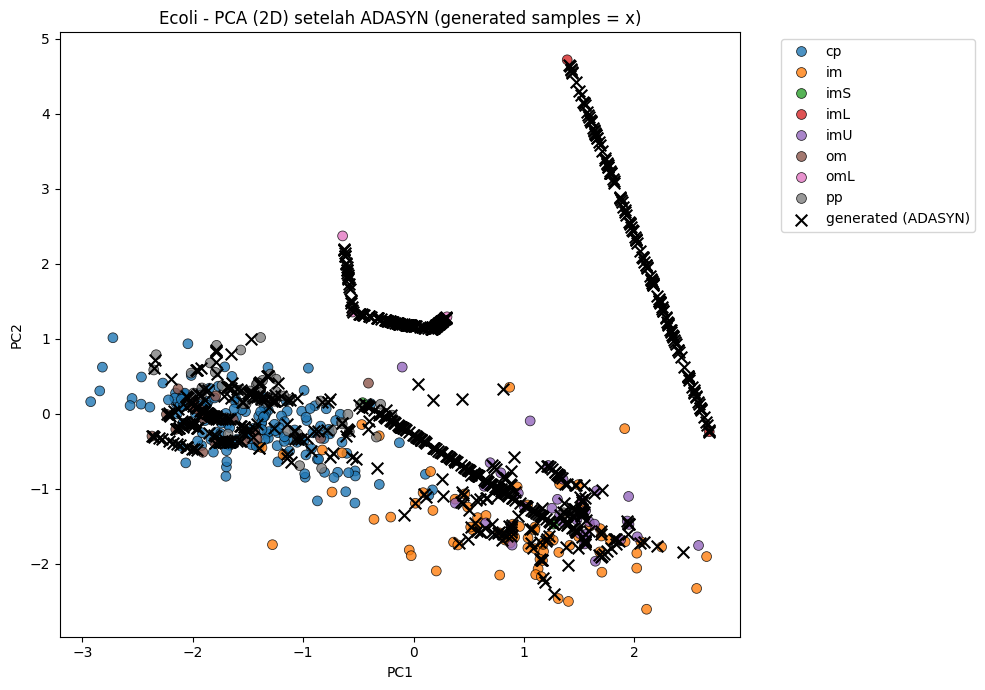

<Figure size 640x480 with 0 Axes>

In [7]:

scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)

pca_res = PCA(n_components=2, random_state=42)
X_res_pca = pca_res.fit_transform(X_res_scaled)

df_res_plot = pd.DataFrame({
    "PC1": X_res_pca[:,0],
    "PC2": X_res_pca[:,1],
    "class": y_res,
    "is_synthetic": is_synthetic
})

plt.figure(figsize=(10,7))
# plot data asli
sns.scatterplot(data=df_res_plot[df_res_plot["is_synthetic"]==False],
                x="PC1", y="PC2", hue="class", palette="tab10",
                s=50, edgecolor="k", alpha=0.8)

# plot data synthetic
synthetic = df_res_plot[df_res_plot["is_synthetic"]==True]
plt.scatter(synthetic["PC1"], synthetic["PC2"],
            marker="x", s=70, c="black", label="generated (ADASYN)")

plt.title("Ecoli - PCA (2D) setelah ADASYN (generated samples = x)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")
plt.tight_layout()
plt.show()

# Optional: save plots
plt.savefig("ecoli_pca_original.png", dpi=200)
plt.savefig("ecoli_pca_adasyn.png", dpi=200)


Kode di bawah ini digunakan untuk menunjukkan dampak penyeimbangan kelas pada dataset Ecoli melalui tiga langkah: data asli, setelah menerapkan SMOTE, dan setelah kombinasi SMOTE dengan ADASYN. Pertama-tama, fitur data dinormalisasi dengan menggunakan `StandardScaler`, kemudian dilakukan pengurangan dimensi menggunakan PCA sehingga hanya tersisa dua komponen utama (`PC1` dan `PC2`). Sebuah fungsi bernama `get_synthetic_mask` dibuat untuk mengidentifikasi sampel sintetis yang dihasilkan oleh teknik oversampling dengan membandingkan dataset yang telah di-resample dengan data aslinya. Data tersebut disimpan dalam DataFrame terpisah untuk masing-masing langkah, dengan kolom `is_synthetic` digunakan untuk menandai sampel yang dihasilkan.

Visualisasi disusun dalam satu gambar yang memiliki tiga subplot. Scatter plot pertama menggambarkan distribusi data asli, dengan warna sesuai kelas. Plot kedua menunjukkan hasil dari SMOTE, di mana sampel asli tetap menggunakan warna kelas, sementara sampel sintetis ditandai dengan simbol hitam `x`. Plot ketiga menampilkan hasil dari kombinasi SMOTE dan ADASYN dengan cara yang serupa. Melalui visualisasi ini, kita dapat dengan jelas mengamati penambahan sampel minoritas, distribusi kelas yang menjadi lebih seimbang, serta dampak metode oversampling terhadap struktur data setelah dilakukan reduksi PCA.

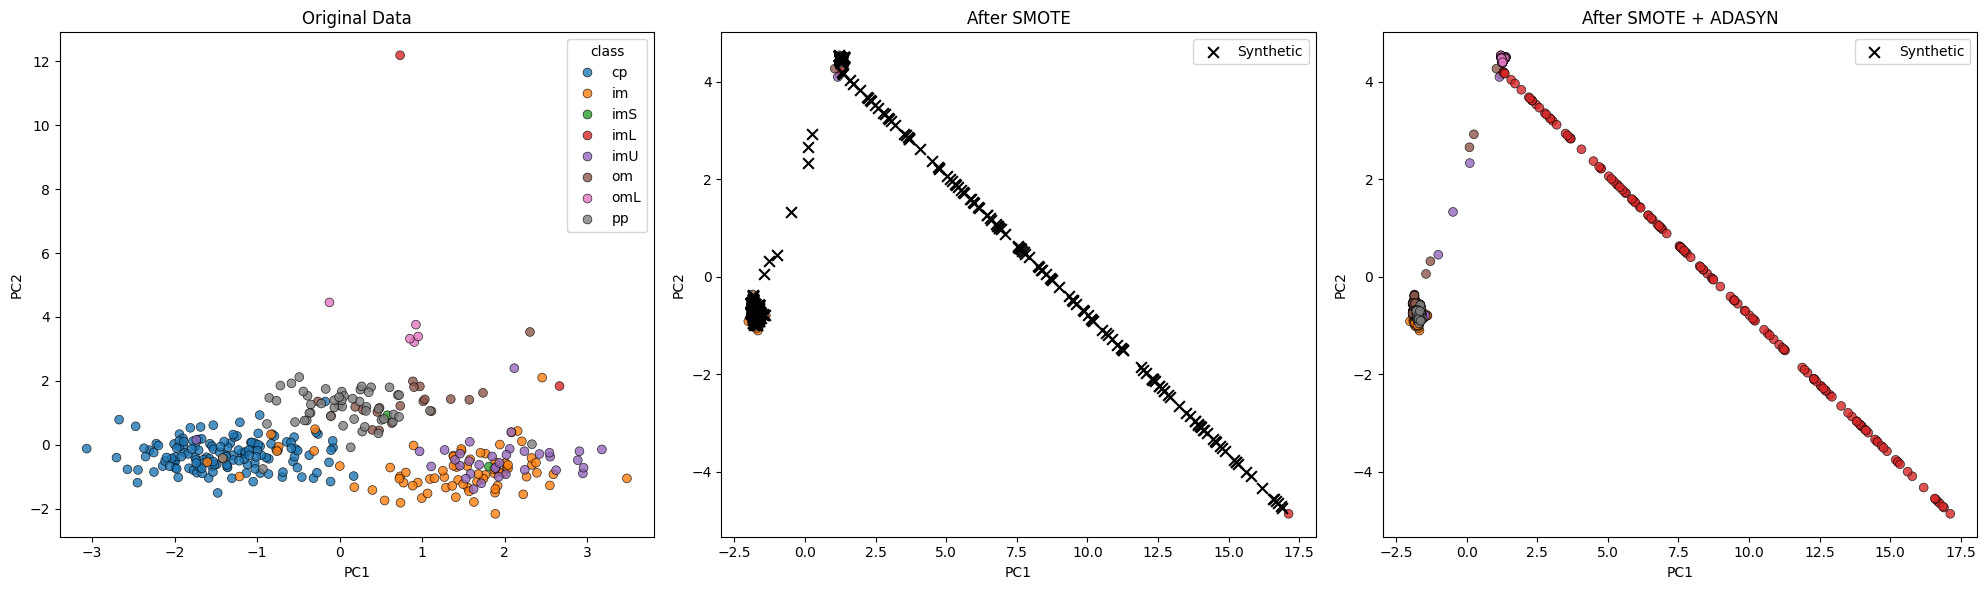

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE, ADASYN
import numpy as np
import pandas as pd

features = ["mcg", "gvh", "lip", "chg", "aac", "alm1", "alm2"]
X = df[features].values
y = df["class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def get_synthetic_mask(X_orig, X_res):
    orig_keys = set(map(tuple, np.round(X_orig, 8)))
    res_keys  = list(map(tuple, np.round(X_res, 8)))
    return np.array([k not in orig_keys for k in res_keys])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

df_orig = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "class": y,
    "is_synthetic": False
})

smote = SMOTE(random_state=42, k_neighbors=1)
X_sm, y_sm = smote.fit_resample(X_scaled, y)

mask_smote = get_synthetic_mask(X_scaled, X_sm)

X_sm_pca = pca.fit_transform(X_sm)
df_sm = pd.DataFrame({
    "PC1": X_sm_pca[:,0],
    "PC2": X_sm_pca[:,1],
    "class": y_sm,
    "is_synthetic": mask_smote
})

adasyn = ADASYN(random_state=42, n_neighbors=1)
X_ada, y_ada = adasyn.fit_resample(X_sm, y_sm)

mask_ada = get_synthetic_mask(X_sm, X_ada)

X_ada_pca = pca.fit_transform(X_ada)
df_ada = pd.DataFrame({
    "PC1": X_ada_pca[:,0],
    "PC2": X_ada_pca[:,1],
    "class": y_ada,
    "is_synthetic": mask_ada
})

fig, axes = plt.subplots(1, 3, figsize=(20,6))

# Original
sns.scatterplot(data=df_orig, x="PC1", y="PC2", hue="class",
                s=40, alpha=0.8, edgecolor="k", ax=axes[0])
axes[0].set_title("Original Data")

# SMOTE
sns.scatterplot(data=df_sm[df_sm["is_synthetic"]==False],
                x="PC1", y="PC2", hue="class",
                s=40, alpha=0.8, edgecolor="k", ax=axes[1], legend=False)
synthetic = df_sm[df_sm["is_synthetic"]==True]
axes[1].scatter(synthetic["PC1"], synthetic["PC2"],
                c="black", marker="x", s=60, label="Synthetic")
axes[1].set_title("After SMOTE")
axes[1].legend()

# SMOTE + ADASYN
sns.scatterplot(data=df_ada[df_ada["is_synthetic"]==False],
                x="PC1", y="PC2", hue="class",
                s=40, alpha=0.8, edgecolor="k", ax=axes[2], legend=False)
synthetic = df_ada[df_ada["is_synthetic"]==True]
axes[2].scatter(synthetic["PC1"], synthetic["PC2"],
                c="black", marker="x", s=60, label="Synthetic")
axes[2].set_title("After SMOTE + ADASYN")
axes[2].legend()

plt.tight_layout()
plt.show()
